# AI & ML Internship — Task 12
## KMeans — Customer Segmentation

### Objective:
- Perform customer segmentation using KMeans clustering
- Use income and spending score features
- Find optimal K using elbow method
- Visualize clusters
- Label customer segments


In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


In [4]:
# Load dataset
df = pd.read_csv("/kaggle/input/customer-segmentation-tutorial-in-python/Mall_Customers.csv")

print("Dataset loaded successfully")
print("Shape:", df.shape)

df.head()


Dataset loaded successfully
Shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
print("Columns:", df.columns.tolist())
df.info()


Columns: ['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [6]:
# Drop CustomerID (not useful for clustering)
features = df[["Annual Income (k$)", "Spending Score (1-100)"]]

print("Selected features shape:", features.shape)
features.head()


Selected features shape: (200, 2)


,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [7]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

print("Features scaled")


Features scaled


In [8]:
inertia_values = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled_features)
    inertia_values.append(km.inertia_)

print("Inertia values computed")


Inertia values computed


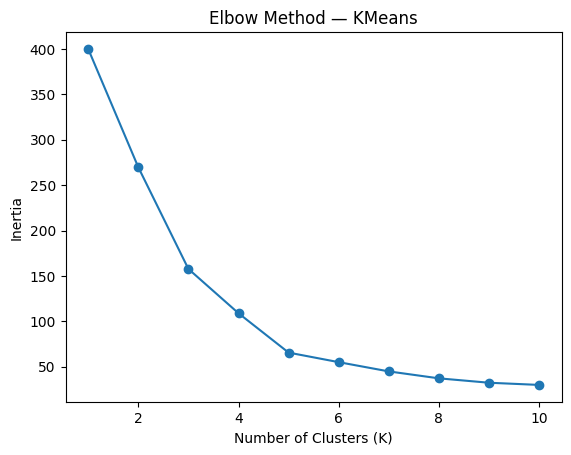

In [9]:
plt.figure()
plt.plot(K_range, inertia_values, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method — KMeans")

plt.savefig("elbow_plot.png", bbox_inches="tight")
plt.show()


In [10]:
optimal_k = 5

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

clusters = kmeans.fit_predict(scaled_features)

print("KMeans trained with K =", optimal_k)


KMeans trained with K = 5


In [11]:
df["Cluster"] = clusters

df.head()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


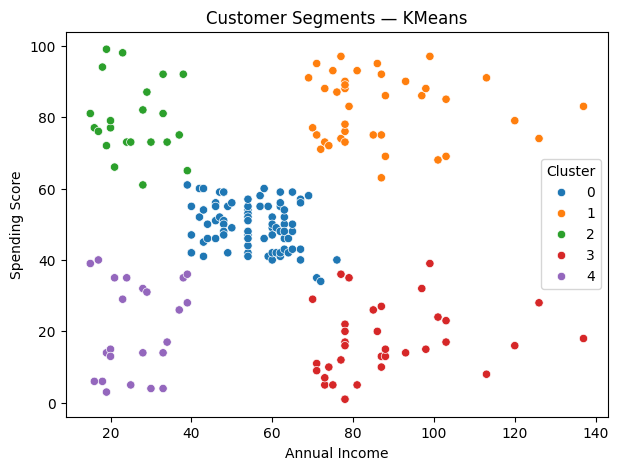

In [12]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x=df["Annual Income (k$)"],
    y=df["Spending Score (1-100)"],
    hue=df["Cluster"],
    palette="tab10"
)

plt.title("Customer Segments — KMeans")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")

plt.savefig("cluster_visualization.png", bbox_inches="tight")
plt.show()


In [13]:
# Convert centers back to original scale
centers = scaler.inverse_transform(kmeans.cluster_centers_)

centers_df = pd.DataFrame(
    centers,
    columns=["Annual Income", "Spending Score"]
)

print("Cluster Centers:")
centers_df


Cluster Centers:


,Annual Income,Spending Score
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


In [15]:
cluster_labels = {
    0: "Average Income — Average Spending",
    1: "High Income — High Spending",
    2: "Low Income — High Spending",
    3: "High Income — Low Spending",
    4: "Low Income — Low Spending"
}

df["Segment"] = df["Cluster"].map(cluster_labels)

df.head()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,Segment
0,1,Male,19,15,39,4,Low Income — Low Spending
1,2,Male,21,15,81,2,Low Income — High Spending
2,3,Female,20,16,6,4,Low Income — Low Spending
3,4,Female,23,16,77,2,Low Income — High Spending
4,5,Female,31,17,40,4,Low Income — Low Spending


In [16]:
df.to_csv("mall_customers_segmented.csv", index=False)

print("Segmented dataset saved")


Segmented dataset saved
